# Spotify Listening Analysis

End-to-end analysis of personal Spotify listening data extracted via the pipeline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="../.env")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

print("Connected to database.")


Connected to database.


## Load Data

In [2]:
with engine.connect() as conn:
    recent_df = pd.read_sql("SELECT * FROM recently_played", conn)
    top_df = pd.read_sql("SELECT * FROM top_tracks", conn)

recent_df["played_at"] = pd.to_datetime(recent_df["played_at"], utc=True)

print(f"Recently played: {len(recent_df)} rows")
print(f"Top tracks: {len(top_df)} rows")
recent_df.head()


Recently played: 53 rows
Top tracks: 151 rows


,played_at,track_id,track_name,artist_id,artist_name,album_name,popularity,played_date,played_hour,played_day_of_week,duration_min
0,2026-04-09 16:49:29.713000+00:00,15inJJqxM31I8sKAUxucEg,TJENENY,7ggM69yllqpMykcU8Tror4,Inkonnu,SPLIT,None,2026-04-09,16,Thursday,2.87
1,2026-04-09 16:49:29.130000+00:00,15inJJqxM31I8sKAUxucEg,TJENENY,7ggM69yllqpMykcU8Tror4,Inkonnu,SPLIT,None,2026-04-09,16,Thursday,2.87
2,2026-04-09 16:49:28.352000+00:00,15inJJqxM31I8sKAUxucEg,TJENENY,7ggM69yllqpMykcU8Tror4,Inkonnu,SPLIT,None,2026-04-09,16,Thursday,2.87
3,2026-04-09 16:49:28.138000+00:00,15inJJqxM31I8sKAUxucEg,TJENENY,7ggM69yllqpMykcU8Tror4,Inkonnu,SPLIT,None,2026-04-09,16,Thursday,2.87
4,2026-04-09 15:52:51.300000+00:00,47prNzqRUL0L9z9qZRRbZj,Ivory,3x7BaW5q1SDNv6bVrbOCmX,MOVEMENT,MOVEMENT,None,2026-04-09,15,Thursday,3.71


## Most Played Artists (Recently)

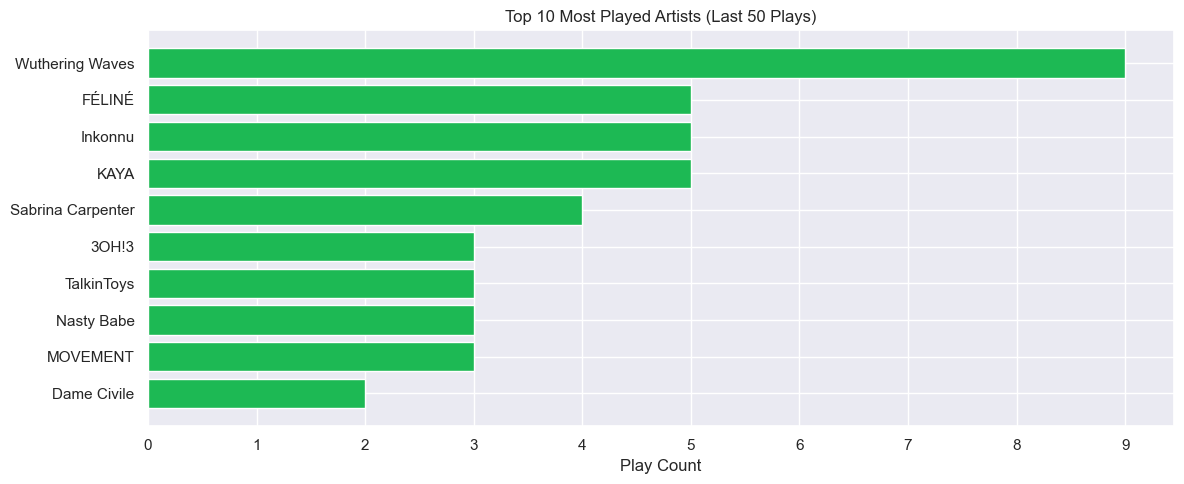

In [3]:
top_artists = (
    recent_df.groupby("artist_name")
    .size()
    .reset_index(name="play_count")
    .sort_values("play_count", ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
bars = ax.barh(top_artists["artist_name"][::-1], top_artists["play_count"][::-1], color="#1DB954")
ax.set_xlabel("Play Count")
ax.set_title("Top 10 Most Played Artists (Last 50 Plays)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


## Listening Activity by Hour

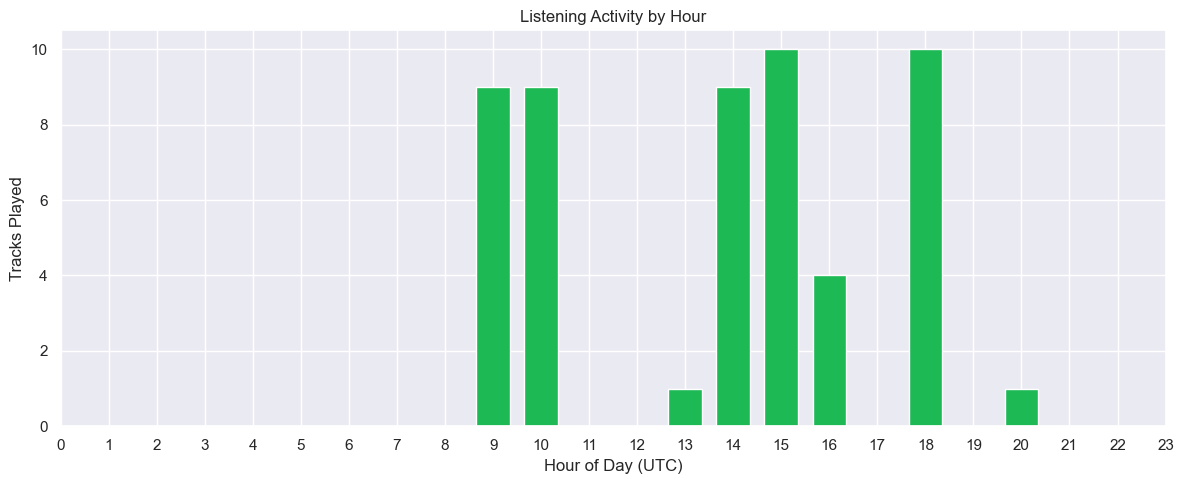

In [4]:
hourly = recent_df.groupby("played_hour").size().reset_index(name="count")

fig, ax = plt.subplots()
ax.bar(hourly["played_hour"], hourly["count"], color="#1DB954", width=0.7)
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Tracks Played")
ax.set_title("Listening Activity by Hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


## Listening Activity by Day of Week

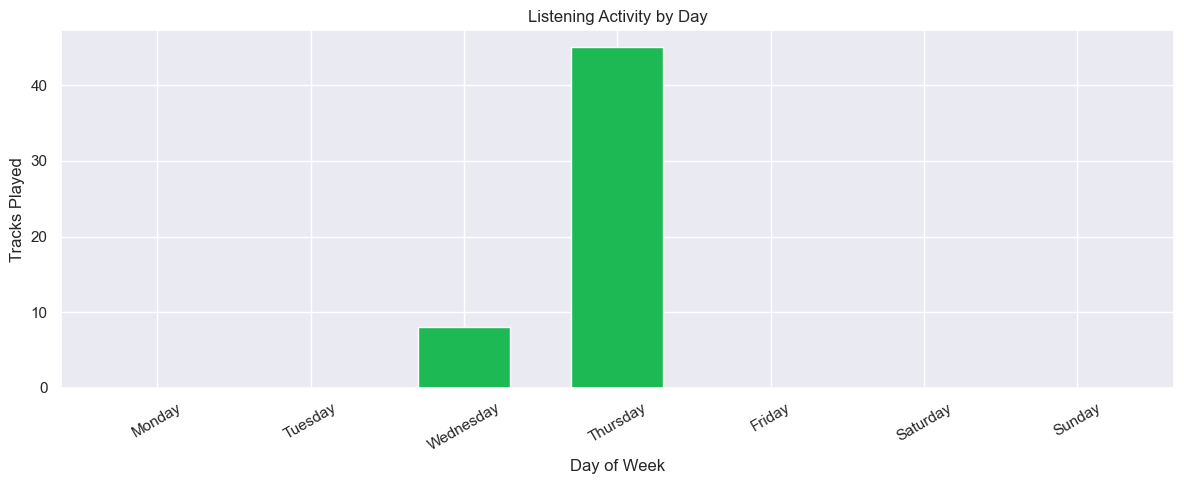

In [5]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = (
    recent_df.groupby("played_day_of_week")
    .size()
    .reindex(day_order, fill_value=0)
    .reset_index(name="count")
)

fig, ax = plt.subplots()
ax.bar(daily["played_day_of_week"], daily["count"], color="#1DB954", width=0.6)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Tracks Played")
ax.set_title("Listening Activity by Day")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Short vs Long Term Top Artists

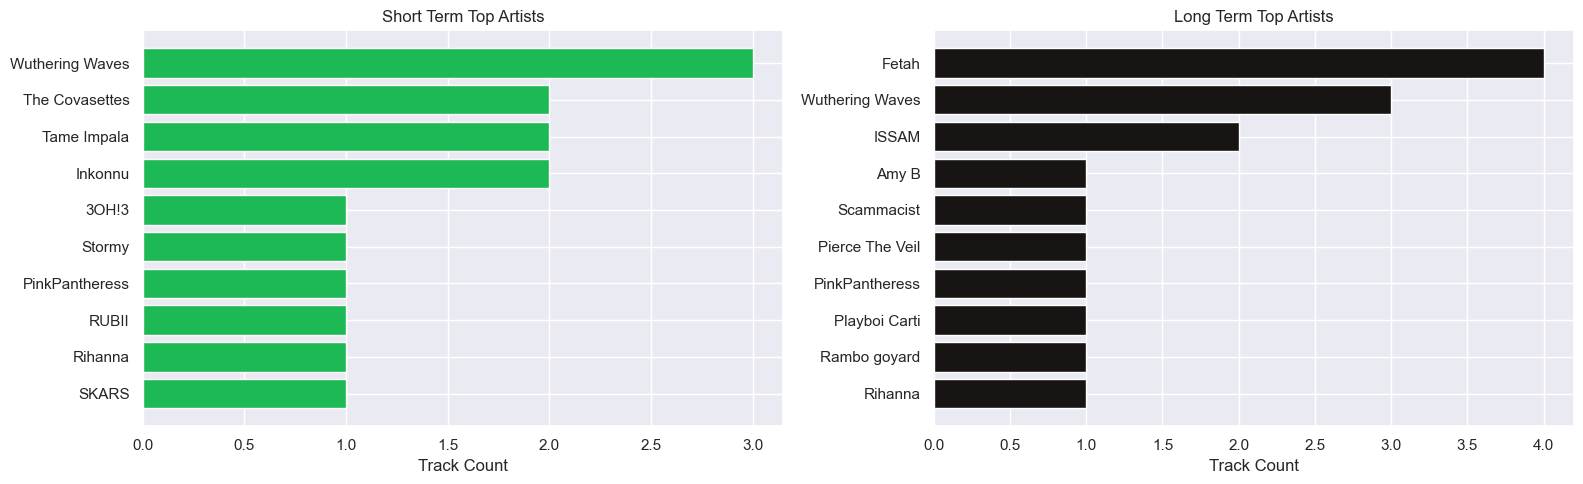

In [7]:
def top_artists_by_range(df, time_range, n=10):
    return (
        df[df["time_range"] == time_range]
        .groupby("artist_name")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(n)
    )

short = top_artists_by_range(top_df, "short_term")
long_ = top_artists_by_range(top_df, "long_term")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(short["artist_name"][::-1], short["count"][::-1], color="#1DB954")
axes[0].set_title("Short Term Top Artists")
axes[0].set_xlabel("Track Count")

axes[1].barh(long_["artist_name"][::-1], long_["count"][::-1], color="#191414")
axes[1].set_title("Long Term Top Artists")
axes[1].set_xlabel("Track Count")

plt.tight_layout()
plt.show()


## Most Played Tracks (Recently)

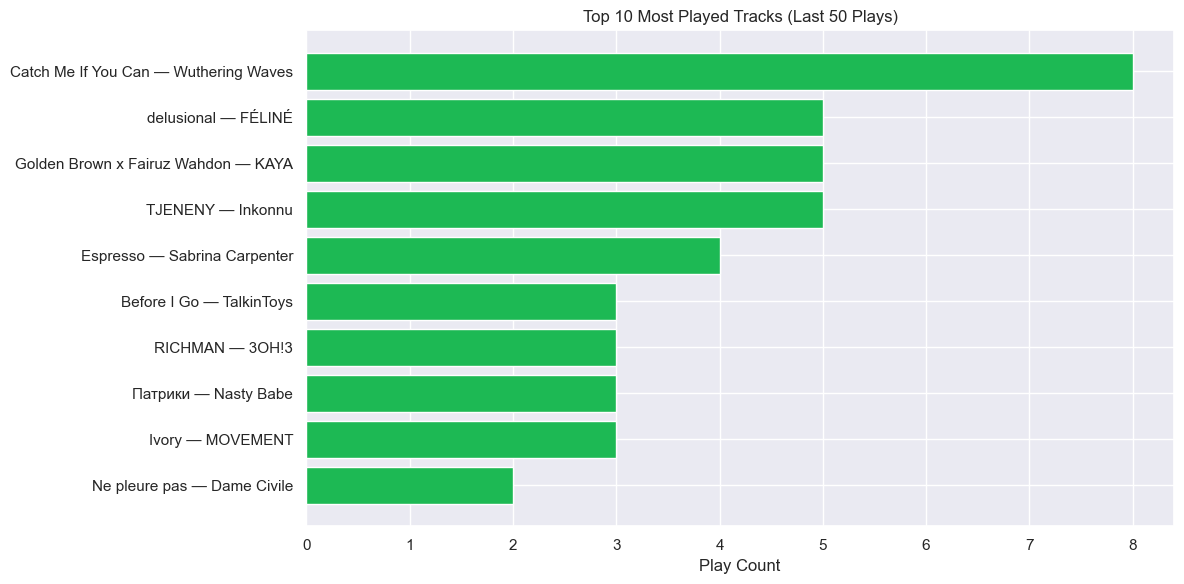

In [8]:
top_tracks_recent = (
    recent_df.groupby(["track_name", "artist_name"])
    .size()
    .reset_index(name="play_count")
    .sort_values("play_count", ascending=False)
    .head(10)
)

top_tracks_recent["label"] = top_tracks_recent["track_name"] + " — " + top_tracks_recent["artist_name"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_tracks_recent["label"][::-1], top_tracks_recent["play_count"][::-1], color="#1DB954")
ax.set_xlabel("Play Count")
ax.set_title("Top 10 Most Played Tracks (Last 50 Plays)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
